In [118]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import sklearn.linear_model as lr


In [119]:
df = pd.read_csv('boston.csv', index_col = 0)
df.describe()
df.info()


<class 'pandas.core.frame.DataFrame'>
Int64Index: 506 entries, 1 to 506
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  black    506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 59.3 KB


2. Dividir la muestra (1 puntos)
* Genere conjuntos de entrenamiento y pruebas con train_test_split .
* Reserve un 33% de la muestra para el conjunto de pruebas.
* Incluya una semilla pseudoaleatoria a su elección, esto lo puede hacer con el
argumento random_state dentro del método train_test_plit.

---
Comentarios: Ultima clase de Alfonso para Holdout del dataset.

In [120]:
from sklearn.model_selection import train_test_split
semilla = 42
test_size_selected = .33

X = df.drop(columns='medv')  # independent variables
y = df.medv                  # target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=test_size_selected, random_state=semilla)


3. Generar modelos (2 puntos)
* Ahora implementaremos dos versiones del modelo lineal:
    - Con intercepto.
    - Sin intercepto.
* Cada versión debe generarse en un nuevo objeto inicializado.
* Posteriormente se deben entrenar los modelos especificando la matriz y vector de entrenamiento.
* Con los modelos entrenados, genere una predicción de la matriz de pruebas con el método .predict().
---
pto 1 y 2: 
* Primero seleccionar columnas descriptores (df.columns) y la variable a describir (df.drop (medv))
* X = sm.add_constant(x) (con intercepto) y sin intercepto X = x
* Identifico el plano de regresión lineal con OLS (Ordinary Least Squares) usaremos el modulo statsmodels con las funciones model = sm.OLS.
* Fitear el modelo con model.fit()
* Evaluar usando model.summary()

pto 3:
* Handout usando X_train, X_test, y_train, y_test = train_test_split
* Estudiar la data. puede servir sns.pairplot, df.describe y ver que pasos del pipeline necesitamos (escalar, normalizar, redefinir variables categoricas OneHotEncoder, etc)
* Crear el pipeline con Pipeline(steps=[('scaler', StandardScaler()), ('model', LinearRegression())])
* Fitear el pipeline con pipeline.fit()

pto 4:
* Predecir con pipeline.predict()

In [121]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

# Definición de modelos.
linear_model_con_intercepto = Pipeline(steps=[
    ('lr', LinearRegression(fit_intercept = True))
])

linear_model_sin_intercepto = Pipeline(steps=[
    ('lr', LinearRegression(fit_intercept = False))
])

# Entrenamiento de modelos
linear_model_con_intercepto.fit(X_train, y_train)
linear_model_sin_intercepto.fit(X_train, y_train)

# Predicción
y_pred_con_intercepto = linear_model_con_intercepto.predict(X_test)
y_pred_sin_intercepto = linear_model_sin_intercepto.predict(X_test)

models = [linear_model_con_intercepto, linear_model_sin_intercepto]

4. Obtención de métricas (1 puntos)
* Ahora generaremos una función llamada report_scores que ingrese como argumentos el vector de datos predichos y el vector de datos por validar.
* La función debe imprimir las métricas del Error Cuadrático Promedio y $R2$.
* Reporte las métricas para ambos modelos. En base a ello, seleccione el mejor modelo.

---

pto 1 y 2:
* implementar
def report_scores(y_pred, y_test):
    print('Error Cuadrático Promedio:', mean_squared_error(y_test, y_pred))
    print('R2:', r2_score(y_test, y_pred))

pto 3:
* Interpretar los resultados del pto anterior (markdown, explicación, ver clase del martes)



In [122]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
def report_scores(y_test, y_pred):
    print('R2:', r2_score(y_test, y_pred))
    print('MSE:', mean_squared_error(y_test, y_pred))
    print('RMSE:', mean_squared_error(y_test, y_pred, squared=False))
    print('MAE:', mean_absolute_error(y_test, y_pred))
    

for model in models:
    print(model)
    report_scores(y_test, model.predict(X_test))
    print('-' * 80)

Pipeline(steps=[('lr', LinearRegression())])
R2: 0.7261570836552478
MSE: 20.72402343733974
RMSE: 4.55236459846306
MAE: 3.148255754816827
--------------------------------------------------------------------------------
Pipeline(steps=[('lr', LinearRegression(fit_intercept=False))])
R2: 0.6881037280185596
MSE: 23.60384463049168
RMSE: 4.858378806813203
MAE: 3.2236891684064832
--------------------------------------------------------------------------------


5. Refactorización del modelo (1 puntos)
* Genere una función llamada fetch_features que ingrese como argumentos la base de datos y el nombre del vector objetivo. El nombre del vector debe ser medv por defecto.
* La función debe retornar una lista con las correlaciones entre cada atributo y el vector objetivo y su nombre.
* Reporte brevemente cuales son los 6 atributos con una mayor correlación absoluta con medv (de mayor a menor correlación).
---
pto 1 y 2:
* implementar (ver clase martes)
def fetch_features(df, target='medv'):
    corr = df.corr()
    corr_target = corr[target].sort_values(ascending=False)
    return corr_target.index[1:6], corr_target[1:6]
    
pto 3:
* Interpretar los resultados del pto anterior (markdown, explicación, ver clase del martes)

In [123]:
def fetch_features(df, target='medv'):
    corr = df.corr().abs()
    corr_target = corr[target].sort_values(ascending=False)
    return pd.DataFrame(corr_target, index=corr_target.index).drop(target)

corr_features = fetch_features(df)
corr_features

,medv
lstat,0.737663
rm,0.695360
ptratio,0.507787
indus,0.483725
tax,0.468536
nox,0.427321
crim,0.388305
rad,0.381626
age,0.376955
zn,0.360445


In [124]:
corr_features[:6]

,medv
lstat,0.737663
rm,0.695360
ptratio,0.507787
indus,0.483725
tax,0.468536
nox,0.427321


6. Refactorización del modelo predictivo (2 puntos)
* Genere otros conjuntos de entrenamiento y validación en base a una matriz con los 6 atributos identificados en el ejercicio anterior, y el vector objetivo.
* Entrene un modelo en base al mejor desempeño.
* Reporte las métricas para el nuevo modelo.
---
pto 1:
* Primero identificar cuales son las 6 variables con mayor correlación con medv (de mayor a menor correlación)
* Segmentar data con X_train, X_test, y_train, y_test = train_test_split para las 6 columnas con mayor correlación con medv  

pto 2:
* Ir probando con las formas que vimos en clase: VIF, Pvalue (P > |t|), Cond number, AIC/BIC, 
Modelo full
Modelo VIF
Modelo pvalue
Modelo con el intercepto
* Si la solución pasa por usar el modulo sm, el seleccionar el mejor modelo pasa por usar .summary() y ver los 4 indicadores que mencionamos.
* Si la solución para por usar sklearn, entonces el modelo de mejor desempeño es el modelo de las 6 columnas de mayor correlación con medv. 

pto 3:
* usar report_scores del requerimiento 4


In [125]:
X_corr = df[corr_features['medv'][:6].index]  # selección de variables con mayor correlación
X_train_corr, X_test_corr, _, _ = train_test_split(X_corr, y, test_size=test_size_selected, random_state=semilla)


In [126]:
# Definición de modelos.
linear_model_con_intercepto_corr = Pipeline(steps=[
    ('lr', LinearRegression(fit_intercept = True))
])

# Entrenamiento de modelos
linear_model_con_intercepto_corr.fit(X_train_corr, y_train)

# Predicción
y_pred_con_intercepto_corr = linear_model_con_intercepto_corr.predict(X_test_corr)

# Modelos
models.append(linear_model_con_intercepto_corr)

print(model)
report_scores(y_test, linear_model_con_intercepto_corr.predict(X_test_corr))
print('-' * 80)

Pipeline(steps=[('lr', LinearRegression(fit_intercept=False))])
R2: 0.6696607622948445
MSE: 24.999580766427155
RMSE: 4.999958076466958
MAE: 3.512683490971634
--------------------------------------------------------------------------------


7. Predicción de casos (2 puntos): A continuación se generaron dos arrays que representan el peor escenario posible (worst_neighbor) y el mejor escenario posible (best_neighbor). Las variables representan, para cada caso, los valores de los siguientes atributos (en el mismo orden entregado): 'lstat', 'rm', 'ptratio', 'indus', 'tax', 'nox'. 

```python
    worst_neighbor = np.array([37.9, 12.6, 3.5, 27.7, 187, 0.87]).reshape(1,-1)
    best_neighbor = np.array([1.73, 22, 8.7, 0.46, 711, 0.38]).reshape(1,-1)
```
* Ingrese los arrays en el modelo entrenado en el ejercicio anterior, y reporte la
predicción entregada por el modelo.
---
Lo que habría que hacer es utilizar esos valores para predecir el medv de cada caso.

,lstat,rm,ptratio,indus,tax,nox
worst,37.9,3.5,12.6,27.7,187.0,0.87
best,1.73,8.7,22.0,0.46,711.0,0.38


Para worst_neighbor, la predicción es: y_pred = 1.293027790412129
Para best_neighbor, la predicción es: y_pred = 35.41514026916968
22.532806324110698
21.643712574850294
22.970796460176988
            lstat          rm     ptratio       indus         tax         nox
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000
mean    12.653063    6.284634   18.455534   11.136779  408.237154    0.554695
std      7.141062    0.702617    2.164946    6.860353  168.537116    0.115878
min      1.730000    3.561000   12.600000    0.460000  187.000000    0.385000
25%      6.950000    5.885500   17.400000    5.190000  279.000000    0.449000
50%     11.360000    6.208500   19.050000    9.690000  330.000000    0.538000
75%     16.955000    6.623500   20.200000   18.100000  666.000000    0.624000
max     37.970000    8.780000   22.000000   27.740000  711.000000    0.871000


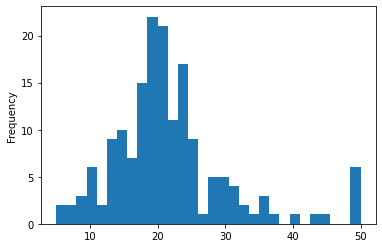

In [127]:
# worst_neighbor = np.array([37.9, 12.6, 3.5, 27.7, 187, 0.87])  # me parece que en el enunciado se equivocaron en el orden de las variables en esta línea. 'rm' y 'ptratio' están al reves. Mirar min y max de la base.
# best_neighbor = np.array([1.73, 22, 8.7, 0.46, 711, 0.38])
worst_neighbor = np.array([37.9, 3.5, 12.6,  27.7, 187, 0.87])
best_neighbor = np.array([1.73, 8.7, 22, 0.46, 711, 0.38])

neighbors = pd.DataFrame(columns=['lstat', 'rm', 'ptratio', 'indus', 'tax', 'nox'],index=['worst', 'best'])
neighbors.loc['worst'] = worst_neighbor
neighbors.loc['best'] = best_neighbor
display(neighbors)
y_pred_neighbors = linear_model_con_intercepto_corr.predict(neighbors)
print(f'Para worst_neighbor, la predicción es: y_pred = {y_pred_neighbors[0]}')
print(f'Para best_neighbor, la predicción es: y_pred = {y_pred_neighbors[1]}')
print(y.mean())
print(y_test.mean())
print(y_train.mean())
y_test.plot(kind='hist', bins=30);
print(X_corr.describe())